In [1]:
import sys
sys.path.append("..")
from src.data_loader import load_colonist_data
import pandas as pd
import matplotlib.pyplot as plt

pawns_df, skills_df, merged_df, pivot_df, traits_df = load_colonist_data("../logs/09_04_2026.rws")

### 1. Find skills with an average level lower than 4
- Find skills with low level to identify gaps in the colony and recruit people with those skills.

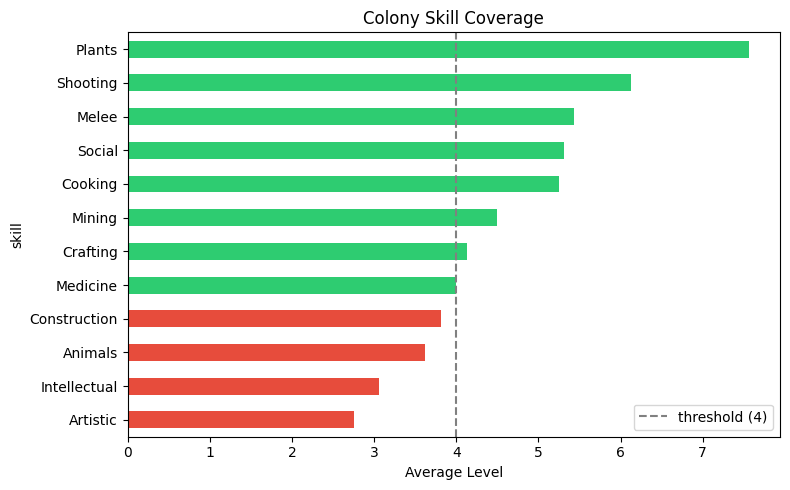

In [2]:
avg_skills = pivot_df.mean().sort_values()
colors = ["#e74c3c" if s < 4 else "#2ecc71" for s in avg_skills]

fig, ax = plt.subplots(figsize=(8, 5))                                                                                                                                                                  
avg_skills.plot(kind="barh", ax=ax, color=colors)                                                                                                                                                       
ax.axvline(x=4, color="gray", linestyle="--", label="threshold (4)")                                                                                                                                    
ax.set_title("Colony Skill Coverage")                                                                                                                                                                   
ax.set_xlabel("Average Level")
ax.legend()                                                                                                                                                                                             
plt.tight_layout()

In [3]:
low_skills = avg_skills[avg_skills < 4].index.tolist()
print(f"This colony needs colonist with {low_skills} skills.")

This colony needs colonist with ['Artistic', 'Intellectual', 'Animals', 'Construction'] skills.


### 2. Analyse Role Concentration (1)
- If a one colonist is resposible for multiple skills, the colony becomes vulnerable in their absence.
- Extract the top 2 levels for each skill and calculate gap.

In [4]:
top2_levels_df = pivot_df.apply(lambda col: col.nlargest(2), axis = 0) # default: axis = 0(by column), 1(by row)

top2_list = top2_levels_df.stack().reset_index()
top2_list.columns = ["first", "skill", "level"]
top2_list = top2_list.dropna(subset=["level"])
top2_list = top2_list.sort_values(['skill', 'level'], ascending=[True, False])

first = top2_list.groupby('skill').nth(0)
second = top2_list.groupby('skill').nth(1)

top2_df = first.merge(second, on='skill', suffixes=('_1st', '_2nd'))
top2_df['gap'] = top2_df['level_1st'] - top2_df['level_2nd']
top2_df

,first_1st,skill,level_1st,first_2nd,level_2nd,gap
0,그레이시,Animals,11.0,루드밀라,10.0,1.0
1,히스이스,Artistic,14.0,헤스크,10.0,4.0
2,헤스크,Construction,17.0,나나미,15.0,2.0
3,루드밀라,Cooking,14.0,마나부,14.0,0.0
4,티코,Crafting,16.0,나나미,13.0,3.0
5,이리나,Intellectual,16.0,티코,15.0,1.0
6,이리나,Medicine,15.0,피노보,13.0,2.0
7,마룰로,Melee,13.0,피노보,11.0,2.0
8,마나부,Mining,14.0,나나미,12.0,2.0
9,그레이시,Plants,15.0,마룰로,14.0,1.0


### 3. Analyse Role Concentration (2)
- If the gap between the top 2 colonists in a skill is 3 or more, the colony is dangerously reliant on one person.
- Identify those skills and flag them as needing a backup colonist.

In [19]:
gap_over_three = top2_df[top2_df['gap'] >= 3]

print("We need backup colonist with skill: ")
for skill in gap_over_three['skill']:
    print(f"    {skill}")

We need backup colonist with skill: 
    Artistic
    Crafting


### 4. Analyse Role Concentration (3)

- Visualise the skill gap between the top 2 colonists for each skill.
- Highlight skills with a gap of 3 or more in red to identify critical single points of failure. 

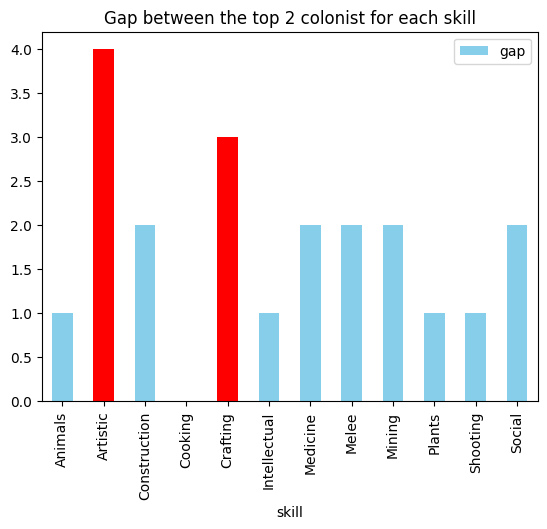

In [26]:
colors = ['red' if x >= 3 else 'skyblue' for x in top2_df['gap']]

top2_df.plot(kind = 'bar', x = 'skill', y = 'gap', color = colors)

plt.title("Gap between the top 2 colonist for each skill")
plt.show()